# Automatic Tumor Segmentation in PET-CT Images

This notebook implements a hybrid intensity and texture-based approach for tumor segmentation using:

- Adaptive Thresholding
- Morphological Operations
- Contour Detection
- Feature Extraction

Dataset: PET-CT images  
Total Images Processed: 200+ (Batch Processing)

SECTION 1: Imports

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd

SECTION 2: Load and Visualize Sample Image

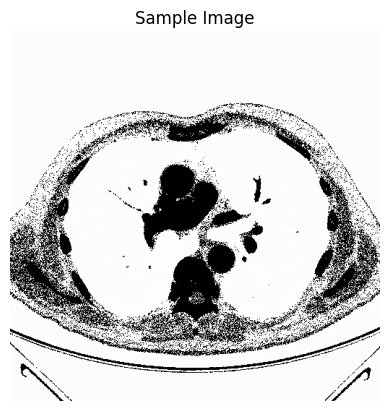

In [2]:
img = cv2.imread('../data/2D Images/ID_0000_Z_0142.tif', 0)

if img is None:
    print("Error: Image not loaded. Please check the file path and name.")
else:
    plt.imshow(img, cmap='gray')
    plt.title("Sample Image")
    plt.axis('off')
    plt.show()

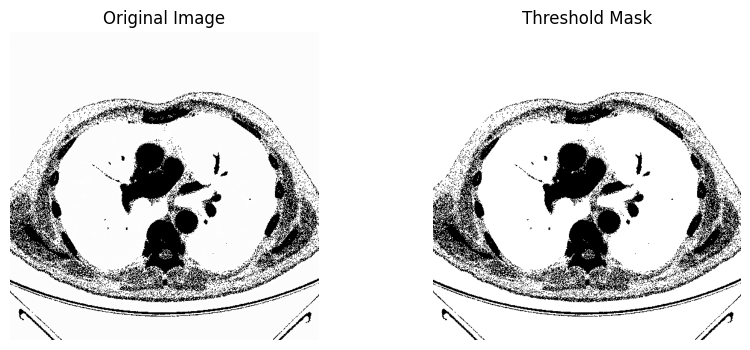

In [3]:
_, mask = cv2.threshold(img, 150, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Threshold Mask")
plt.imshow(mask, cmap='gray')
plt.axis('off')

plt.show()

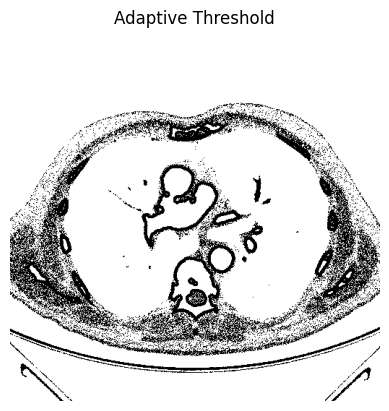

In [6]:
# Ensure grayscale
if len(img.shape) == 3:
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Convert to uint8 safely
if img.dtype != 'uint8':
    img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)
    img = img.astype('uint8')

adaptive_mask = cv2.adaptiveThreshold(
    img,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    11,
    2
)

plt.imshow(adaptive_mask, cmap='gray')
plt.title("Adaptive Threshold")
plt.axis('off')
plt.show()

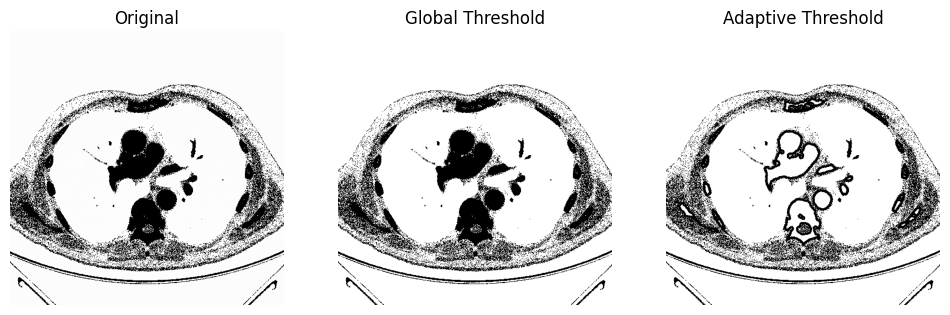

In [7]:
# Global threshold
_, mask_global = cv2.threshold(img, 150, 255, cv2.THRESH_BINARY)

# Adaptive threshold (already done)
mask_adaptive = adaptive_mask

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1,3,2)
plt.title("Global Threshold")
plt.imshow(mask_global, cmap='gray')
plt.axis('off')

plt.subplot(1,3,3)
plt.title("Adaptive Threshold")
plt.imshow(mask_adaptive, cmap='gray')
plt.axis('off')

plt.show()

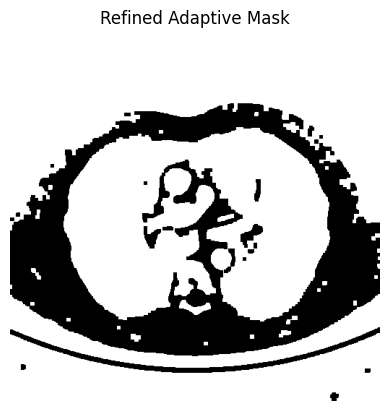

In [8]:
kernel = np.ones((5,5), np.uint8)

clean_adaptive = cv2.morphologyEx(mask_adaptive, cv2.MORPH_OPEN, kernel)
clean_adaptive = cv2.morphologyEx(clean_adaptive, cv2.MORPH_CLOSE, kernel)

plt.imshow(clean_adaptive, cmap='gray')
plt.title("Refined Adaptive Mask")
plt.axis('off')
plt.show()

In [20]:
import os
import cv2
import numpy as np

input_folder = "../data/2D Images/"
output_folder = "../results/"

os.makedirs(output_folder, exist_ok=True)

for filename in os.listdir(input_folder):
    if filename.endswith(".tif"):
        
        path = os.path.join(input_folder, filename)
        img = cv2.imread(path, 0)

        if img is None:
            continue

        # Step 1: Threshold
        _, mask = cv2.threshold(img, 150, 255, cv2.THRESH_BINARY)

        # Step 2: Morphology
        kernel = np.ones((5,5), np.uint8)
        clean_mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
        clean_mask = cv2.morphologyEx(clean_mask, cv2.MORPH_CLOSE, kernel)

        # Step 3: Contours
        contours, _ = cv2.findContours(clean_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        output = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
        cv2.drawContours(output, contours, -1, (0,255,0), 2)

        # Save result
        save_path = os.path.join(output_folder, filename)
        cv2.imwrite(save_path, output)

print("Processing Done ✅")

Processing Done ✅


In [21]:
h, w = img.shape

margin = 20

# Zero out borders
clean_adaptive[:margin, :] = 0
clean_adaptive[-margin:, :] = 0
clean_adaptive[:, :margin] = 0
clean_adaptive[:, -margin:] = 0

filtered_contours = []

for cnt in contours:
    area = cv2.contourArea(cnt)
    x, y, w, h = cv2.boundingRect(cnt)

    # Ignore:
    # 1. Too large (body)
    # 2. Too small (noise)
    # 3. Touching border

    if 500 < area < 20000:
        if x > 10 and y > 10 and (x+w) < img.shape[1]-10 and (y+h) < img.shape[0]-10:
            filtered_contours.append(cnt)

In [1]:
tumor_contour = max(filtered_contours, key=cv2.contourArea)

NameError: name 'filtered_contours' is not defined